# 01 — EDA Dataset Utama: Tumpukan TBS di Gerbang PKS

**Dataset:** *Annotated Datasets of Oil Palm Fruit Bunch Piles for Ripeness Grading* (Scientific Data, 2023)
Diambil di bagian grading PKS, Kalimantan Selatan · Lisensi CC-BY 4.0

**Tujuan notebook ini bukan sekadar menghitung isi dataset.** Yang dicari adalah
jawaban atas empat pertanyaan yang menentukan desain model:

1. Berapa **unit sampel sebenarnya** — gambar, atau tumpukan?
2. Apakah **split resmi** bisa dipercaya?
3. Seberapa besar objek yang harus dideteksi, dan apa implikasinya ke resolusi?
4. Apakah pembagian kelas yang ada sudah bentuk terbaik untuk tugas ini?

Setiap temuan ditutup dengan **implikasi konkret** ke keputusan teknis.

In [1]:
from pathlib import Path
import sys, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))

import vizstyle as vs
vs.apply_style()

ROOT = Path.cwd().parents[1]              # neraca-minyak/
DATA = ROOT / "data" / "raw" / "piles-kalsel"
SPLITS = {"train": "train_rev2/train", "valid": "valid_rev2/valid", "test": "test_rev2/test"}

print("root :", ROOT)
print("data :", DATA, "|", "ADA" if DATA.exists() else "TIDAK DITEMUKAN")

root : D:\LOMBA\COMPFEST\neraca-minyak
data : D:\LOMBA\COMPFEST\neraca-minyak\data\raw\piles-kalsel | ADA


## 1. Membangun indeks dataset

Nama berkasnya sendiri sudah membawa informasi penting:

```
frame1--10-_png.rf.1911a754a67db08da4ed79abd150ba18.jpg
└─┬──┘  └┬┘        └────────────┬──────────────────┘
 tumpukan  frame ke-           hash ekspor Roboflow
```

Bagian sebelum `--` adalah **identitas tumpukan/video**, dan bagian sesudahnya
nomor frame. Suffix `.rf.` menandakan dataset ini diekspor lewat Roboflow —
yang split bawaannya acak **per gambar**, bukan per tumpukan. Kita catat kedua
informasi itu sejak awal karena keduanya menentukan validitas seluruh eksperimen.

In [2]:
def parse_pile(stem: str):
    """Ambil id tumpukan dan nomor frame dari nama berkas."""
    head = stem.split("_png")[0]           # frame1--10-
    if "--" in head:
        pile, frame = head.split("--", 1)
        frame = re.sub(r"[^0-9]", "", frame)
        frame = int(frame) if frame else -1
    else:
        pile, frame = head, -1
    return pile, frame

def pile_group(pile: str) -> str:
    """Kelompok tumpukan: buang digit di belakang (framementah12 -> framementah)."""
    return re.sub(r"\d+$", "", pile)

img_rows, box_rows = [], []
for split, sub in SPLITS.items():
    d = DATA / sub
    for img in sorted(d.glob("*.jpg")):
        pile, frame = parse_pile(img.stem)
        lab = img.with_suffix(".txt")
        boxes = []
        if lab.exists():
            for line in lab.read_text().strip().splitlines():
                p = line.split()
                if len(p) >= 5:
                    boxes.append((int(p[0]), *map(float, p[1:5])))
        img_rows.append({
            "split_resmi": split, "file": img.name, "path": str(img),
            "pile": pile, "group": pile_group(pile), "frame": frame,
            "n_boxes": len(boxes),
        })
        for cid, x, y, w, h in boxes:
            box_rows.append({
                "split_resmi": split, "file": img.name, "pile": pile,
                "group": pile_group(pile), "class_id": cid,
                "x": x, "y": y, "w": w, "h": h,
            })

imgs = pd.DataFrame(img_rows)
boxes = pd.DataFrame(box_rows)
boxes["kelas"] = boxes["class_id"].map(vs.CLASS_NAMES)

print(f"{len(imgs):,} gambar   {len(boxes):,} kotak anotasi   {imgs['pile'].nunique()} tumpukan unik")

4,160 gambar   14,558 kotak anotasi   91 tumpukan unik


In [3]:
ringkas = (imgs.groupby("split_resmi")
    .agg(gambar=("file", "count"),
         tumpukan=("pile", "nunique"),
         kotak=("n_boxes", "sum"),
         kotak_per_gambar=("n_boxes", "mean"))
    .reindex(["train", "valid", "test"]))
ringkas["kotak_per_gambar"] = ringkas["kotak_per_gambar"].round(2)
ringkas.loc["TOTAL"] = [len(imgs), imgs["pile"].nunique(), len(boxes),
                        round(len(boxes)/len(imgs), 2)]
ringkas

,gambar,tumpukan,kotak,kotak_per_gambar
split_resmi,,,,
train,2908.0,91.0,10140.0,3.49
valid,835.0,91.0,3008.0,3.60
test,417.0,87.0,1410.0,3.38
TOTAL,4160.0,91.0,14558.0,3.50


> **Temuan pertama, dan ini yang paling menentukan.**
> Kolom `tumpukan` menunjukkan angka yang jauh lebih kecil daripada `gambar`.
> Dataset ini terlihat seperti ribuan sampel, tetapi secara statistik unitnya
> adalah **tumpukan** — dan jumlahnya jauh lebih sedikit. Semua ekspektasi soal
> ukuran sampel harus dihitung ulang dari angka itu, bukan dari jumlah gambar.

## 2. Distribusi kelas

Enam kelas, tetapi perhatikan: `class_id` di berkas label tersusun **alfabetis**,
bukan menurut urutan kematangan. Ini jebakan yang mahal — kalau `class_id`
dipakai apa adanya sebagai skala ordinal, model justru diajari urutan yang salah.

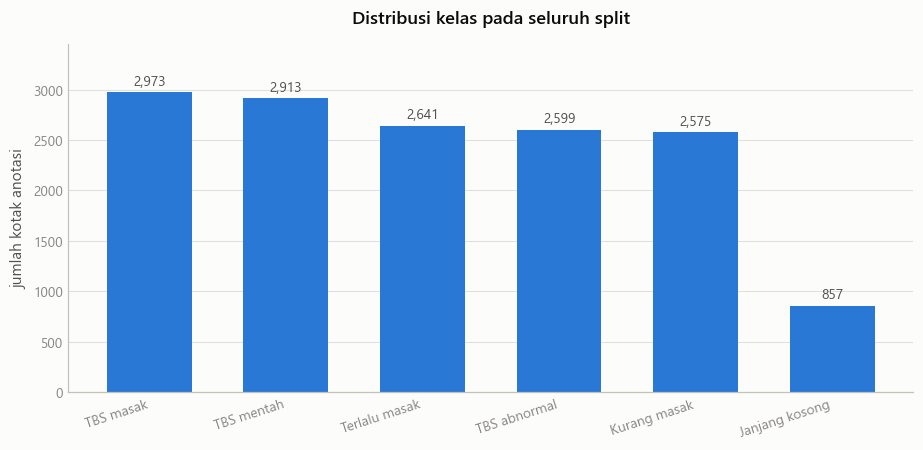

,kelas,jumlah,persen
0,TBS masak,2973,20.42
1,TBS mentah,2913,20.01
2,Terlalu masak,2641,18.14
3,TBS abnormal,2599,17.85
4,Kurang masak,2575,17.69
5,Janjang kosong,857,5.89


In [4]:
dist = (boxes["kelas"].value_counts()
        .rename_axis("kelas").reset_index(name="jumlah"))
dist["persen"] = (dist["jumlah"] / dist["jumlah"].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
b = ax.bar(dist["kelas"], dist["jumlah"], color=vs.PRIMARY, width=0.62)
vs.label_bars(ax, b)
ax.set_ylabel("jumlah kotak anotasi")
ax.set_title("Distribusi kelas pada seluruh split")
ax.set_ylim(0, dist["jumlah"].max() * 1.16)
plt.xticks(rotation=18, ha="right")
plt.tight_layout(); plt.show()

dist

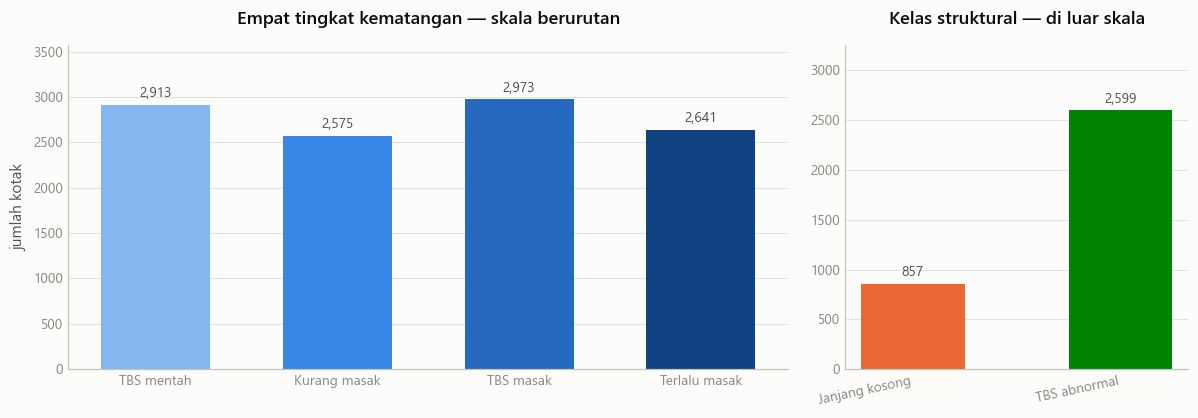

Total tingkat kematangan : 11,102 kotak
Total kelas struktural   : 3,456 kotak


In [5]:
# Urutan kematangan yang SEBENARNYA, terlepas dari class_id.
ord_counts = [int((boxes["class_id"] == cid).sum()) for cid in vs.ORDINAL_ORDER]
struct = {vs.CLASS_NAMES[cid]: int((boxes["class_id"] == cid).sum()) for cid in vs.NON_ORDINAL}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9),
                         gridspec_kw={"width_ratios": [2.1, 1]})

ax = axes[0]
b = ax.bar(vs.ORDINAL_LABELS, ord_counts, color=vs.ORDINAL_RAMP, width=0.6)
vs.label_bars(ax, b)
ax.set_title("Empat tingkat kematangan — skala berurutan")
ax.set_ylabel("jumlah kotak")
ax.set_ylim(0, max(ord_counts) * 1.2)

ax = axes[1]
b = ax.bar(list(struct), list(struct.values()),
           color=[vs.CLASS_COLORS[c] for c in vs.NON_ORDINAL], width=0.5)
vs.label_bars(ax, b)
ax.set_title("Kelas struktural — di luar skala")
ax.set_ylim(0, max(struct.values()) * 1.25)
plt.xticks(rotation=12, ha="right")

plt.tight_layout(); plt.show()

print(f"Total tingkat kematangan : {sum(ord_counts):,} kotak")
print(f"Total kelas struktural   : {sum(struct.values()):,} kotak")

> **Implikasi desain.** Empat tingkat kematangan berada pada satu skala
> berurutan; `Janjang kosong` dan `TBS abnormal` **bukan tingkat kematangan** —
> keduanya objek yang secara struktur berbeda. Memaksa keenamnya jadi satu tugas
> klasifikasi datar mengaburkan perbedaan yang nyata itu.
>
> Alternatif yang lebih jujur secara konseptual: detektor menjawab *di mana*
> dengan kelas struktural, lalu model terpisah menjawab *seberapa matang* pada
> skala berurutan.

## 3. Berapa objek per gambar

Menentukan seberapa padat adegan yang harus ditangani detektor.

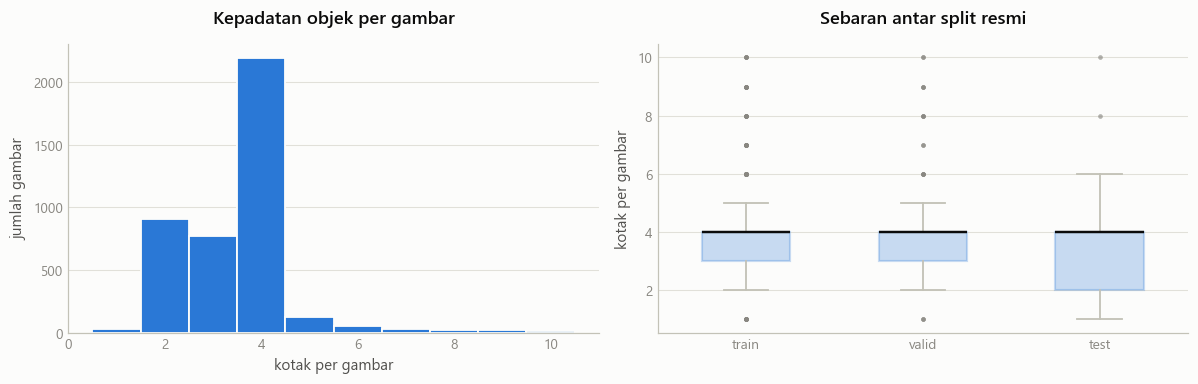

count    4160.00
mean        3.50
std         1.16
min         1.00
25%         3.00
50%         4.00
75%         4.00
max        10.00

gambar tanpa anotasi sama sekali : 0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
vals = imgs["n_boxes"]
bins = np.arange(vals.min() - 0.5, vals.max() + 1.5, 1)
ax.hist(vals, bins=bins, color=vs.PRIMARY, edgecolor=vs.SURFACE, linewidth=1.2)
ax.set_xlabel("kotak per gambar"); ax.set_ylabel("jumlah gambar")
ax.set_title("Kepadatan objek per gambar")

ax = axes[1]
per_split = [imgs.loc[imgs.split_resmi == s, "n_boxes"] for s in ["train", "valid", "test"]]
bp = ax.boxplot(per_split, labels=["train", "valid", "test"], patch_artist=True,
                widths=0.5, medianprops=dict(color=vs.INK, linewidth=1.6),
                flierprops=dict(marker="o", markersize=3,
                                markerfacecolor=vs.INK_MUTED,
                                markeredgecolor="none", alpha=0.4))
for p in bp["boxes"]:
    p.set(facecolor=vs.PRIMARY, alpha=0.25, edgecolor=vs.PRIMARY, linewidth=1.4)
for w in bp["whiskers"] + bp["caps"]:
    w.set(color=vs.BASELINE, linewidth=1.2)
ax.set_ylabel("kotak per gambar")
ax.set_title("Sebaran antar split resmi")

plt.tight_layout(); plt.show()

print(imgs["n_boxes"].describe().round(2).to_string())
print(f"\ngambar tanpa anotasi sama sekali : {(imgs['n_boxes'] == 0).sum()}")

## 4. Geometri kotak — seberapa kecil objeknya?

Ini menentukan resolusi kerja model. Kalau sebagian besar objek tergolong
*small* menurut konvensi COCO (luas < 32² piksel pada citra 416×416), detektor
akan kesulitan dan resolusi jadi faktor pembatas utama.

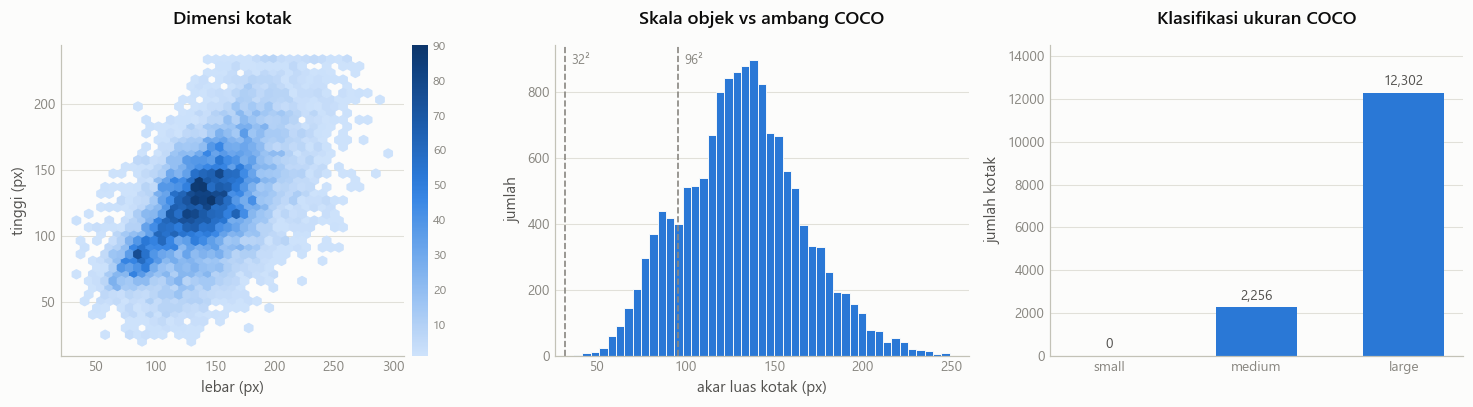

ukuran
large (>96²)        84.5
medium (32²–96²)    15.5

rasio lebar/tinggi  median 1.11   p5 0.78   p95 1.96


In [7]:
IMG = 416
boxes["w_px"] = boxes["w"] * IMG
boxes["h_px"] = boxes["h"] * IMG
boxes["area_px"] = boxes["w_px"] * boxes["h_px"]
boxes["rasio"] = boxes["w_px"] / boxes["h_px"]

def coco_size(a):
    if a < 32**2:  return "small (<32²)"
    if a < 96**2:  return "medium (32²–96²)"
    return "large (>96²)"
boxes["ukuran"] = boxes["area_px"].apply(coco_size)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

ax = axes[0]
hb = ax.hexbin(boxes["w_px"], boxes["h_px"], gridsize=38, mincnt=1,
               cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("seq", vs.SEQUENTIAL))
ax.set_xlabel("lebar (px)"); ax.set_ylabel("tinggi (px)")
ax.set_title("Dimensi kotak")
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, colors=vs.INK_MUTED)

ax = axes[1]
ax.hist(np.sqrt(boxes["area_px"]), bins=45, color=vs.PRIMARY,
        edgecolor=vs.SURFACE, linewidth=0.6)
for t, lbl in [(32, "32²"), (96, "96²")]:
    ax.axvline(t, color=vs.INK_MUTED, linestyle="--", linewidth=1.1)
    ax.annotate(lbl, (t, ax.get_ylim()[1]*0.94), fontsize=8.5,
                color=vs.INK_MUTED, ha="left", xytext=(4, 0),
                textcoords="offset points")
ax.set_xlabel("akar luas kotak (px)"); ax.set_ylabel("jumlah")
ax.set_title("Skala objek vs ambang COCO")

ax = axes[2]
sz = boxes["ukuran"].value_counts().reindex(
    ["small (<32²)", "medium (32²–96²)", "large (>96²)"]).fillna(0)
b = ax.bar(range(len(sz)), sz.values, color=vs.PRIMARY, width=0.55)
vs.label_bars(ax, b)
ax.set_xticks(range(len(sz)))
ax.set_xticklabels(["small", "medium", "large"])
ax.set_ylabel("jumlah kotak")
ax.set_title("Klasifikasi ukuran COCO")
ax.set_ylim(0, sz.max() * 1.18)

plt.tight_layout(); plt.show()

print((boxes["ukuran"].value_counts(normalize=True) * 100).round(1).to_string())
print(f"\nrasio lebar/tinggi  median {boxes['rasio'].median():.2f}"
      f"   p5 {boxes['rasio'].quantile(.05):.2f}   p95 {boxes['rasio'].quantile(.95):.2f}")

## 5. Struktur tumpukan — unit sampel yang sebenarnya

Bagian ini yang paling menentukan cara membagi data.

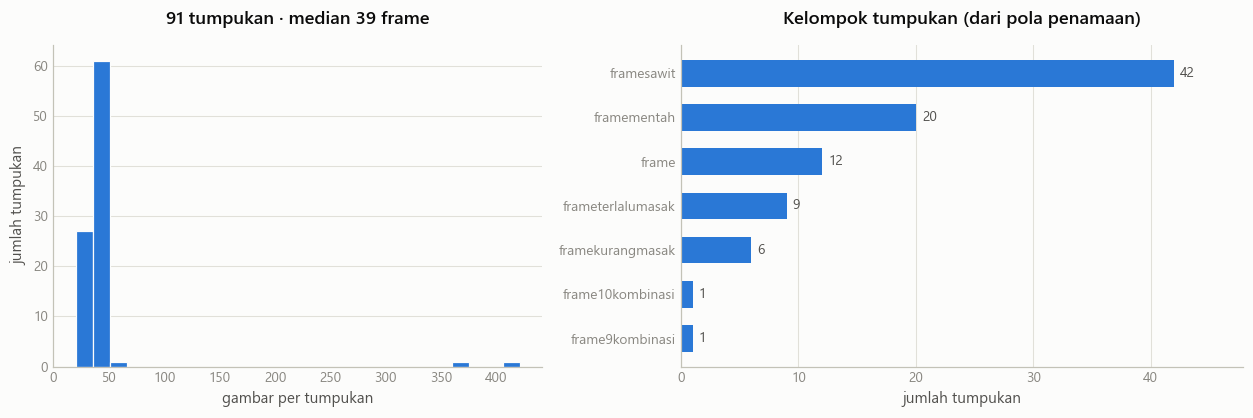

,count,mean,std,min,25%,50%,75%,max
gambar per tumpukan,91.0,45.7,52.6,20.0,35.0,39.0,41.0,421.0


In [8]:
per_pile = (imgs.groupby(["pile", "group"])
            .agg(gambar=("file", "count"), kotak=("n_boxes", "sum"))
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9),
                         gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
ax.hist(per_pile["gambar"], bins=26, color=vs.PRIMARY,
        edgecolor=vs.SURFACE, linewidth=0.8)
ax.set_xlabel("gambar per tumpukan"); ax.set_ylabel("jumlah tumpukan")
ax.set_title(f"{len(per_pile)} tumpukan · median {per_pile['gambar'].median():.0f} frame")

ax = axes[1]
g = per_pile["group"].value_counts()
b = ax.barh(range(len(g)), g.values, color=vs.PRIMARY, height=0.6)
ax.set_yticks(range(len(g))); ax.set_yticklabels(g.index, fontsize=9)
ax.invert_yaxis()
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
for i, v in enumerate(g.values):
    ax.annotate(f"{v}", (v, i), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=vs.INK_SECONDARY)
ax.set_xlabel("jumlah tumpukan")
ax.set_title("Kelompok tumpukan (dari pola penamaan)")
ax.set_xlim(0, g.max() * 1.14)

plt.tight_layout(); plt.show()

per_pile["gambar"].describe().round(1).to_frame("gambar per tumpukan").T

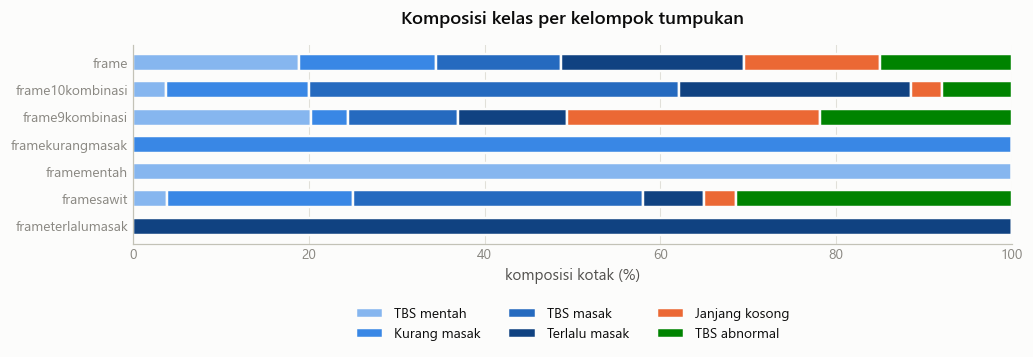

kelas,TBS mentah,Kurang masak,TBS masak,Terlalu masak,Janjang kosong,TBS abnormal
group,,,,,,
frame,18.8,15.6,14.2,20.8,15.6,15.0
frame10kombinasi,3.8,16.3,42.1,26.4,3.5,8.0
frame9kombinasi,20.2,4.2,12.4,12.4,28.8,21.9
framekurangmasak,0.0,100.0,0.0,0.0,0.0,0.0
framementah,100.0,0.0,0.0,0.0,0.0,0.0
framesawit,3.8,21.2,33.0,6.9,3.6,31.4
frameterlalumasak,0.0,0.0,0.0,100.0,0.0,0.0


In [9]:
# Komposisi kelas per kelompok tumpukan — apakah nama kelompok
# benar-benar mencerminkan isinya?
comp = (boxes.groupby(["group", "kelas"]).size()
        .unstack(fill_value=0))
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
order = [vs.CLASS_NAMES[c] for c in vs.ORDINAL_ORDER + vs.NON_ORDINAL]
comp_pct = comp_pct[[c for c in order if c in comp_pct.columns]]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
left = np.zeros(len(comp_pct))
for kelas in comp_pct.columns:
    cid = [k for k, v in vs.CLASS_NAMES.items() if v == kelas][0]
    vals = comp_pct[kelas].values
    ax.barh(range(len(comp_pct)), vals, left=left, height=0.62,
            color=vs.CLASS_COLORS[cid], label=kelas,
            edgecolor=vs.SURFACE, linewidth=1.6)
    left += vals
ax.set_yticks(range(len(comp_pct))); ax.set_yticklabels(comp_pct.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 100); ax.set_xlabel("komposisi kotak (%)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Komposisi kelas per kelompok tumpukan")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), ncol=3)
plt.tight_layout(); plt.show()

comp_pct.round(1)

> **Implikasi ke strategi split.** Kalau kelompok tumpukan punya komposisi
> kelas yang sangat berbeda satu sama lain, membagi tumpukan secara acak murni
> berisiko membuang seluruh kelompok kecil ke satu sisi — dan metrik uji jadi
> tidak mewakili. Split harus **distratifikasi menurut kelompok**.

## 6. Menguji integritas split resmi

Pertanyaannya sederhana: apakah ada tumpukan yang muncul di lebih dari satu split?
Kalau ya, frame yang nyaris identik ada di sisi latih **dan** sisi uji, dan
metrik apa pun yang dihitung dari situ tidak bermakna.

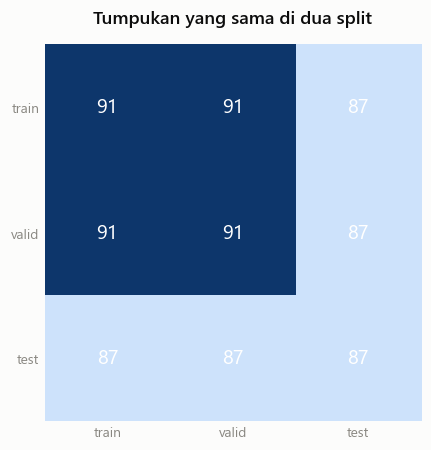

Total tumpukan unik di SELURUH dataset : 91
  train ∩ valid :  91 tumpukan  (100.0% dari valid juga ada di train)
  train ∩ test  :  87 tumpukan  (100.0% dari test juga ada di train)
  valid ∩ test  :  87 tumpukan  (100.0% dari test juga ada di valid)


In [10]:
ids = {s: set(imgs.loc[imgs.split_resmi == s, "pile"]) for s in ["train", "valid", "test"]}
names = ["train", "valid", "test"]

M = np.zeros((3, 3), dtype=int)
for i, a in enumerate(names):
    for j, b in enumerate(names):
        M[i, j] = len(ids[a] & ids[b])

fig, ax = plt.subplots(figsize=(5.2, 4.2))
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seq", vs.SEQUENTIAL)
im = ax.imshow(M, cmap=cmap)
ax.set_xticks(range(3), names); ax.set_yticks(range(3), names)
vs.strip_chart(ax)
ax.set_xticks(range(3)); ax.set_xticklabels(names)
ax.set_yticks(range(3)); ax.set_yticklabels(names)
for i in range(3):
    for j in range(3):
        ax.text(j, i, M[i, j], ha="center", va="center", fontsize=13,
                color="#ffffff" if M[i, j] > M.max()*0.55 else vs.INK)
ax.set_title("Tumpukan yang sama di dua split")
plt.tight_layout(); plt.show()

tot = len(set().union(*ids.values()))
print(f"Total tumpukan unik di SELURUH dataset : {tot}")
for a, b in [("train", "valid"), ("train", "test"), ("valid", "test")]:
    ov = len(ids[a] & ids[b])
    print(f"  {a:5s} ∩ {b:5s} : {ov:3d} tumpukan  "
          f"({ov / len(ids[b]) * 100:5.1f}% dari {b} juga ada di {a})")

> **Kalau angka di luar diagonal tidak nol, split resmi bocor.**
> Konsekuensinya: metrik dari split ini mengukur kemampuan model *menghafal
> tumpukan yang sudah pernah dilihat*, bukan kemampuannya menilai tumpukan baru.
> Notebook 02 membangun split pengganti berbasis tumpukan.

## 7. Sampel visual

Angka tidak menggantikan melihat datanya sendiri.

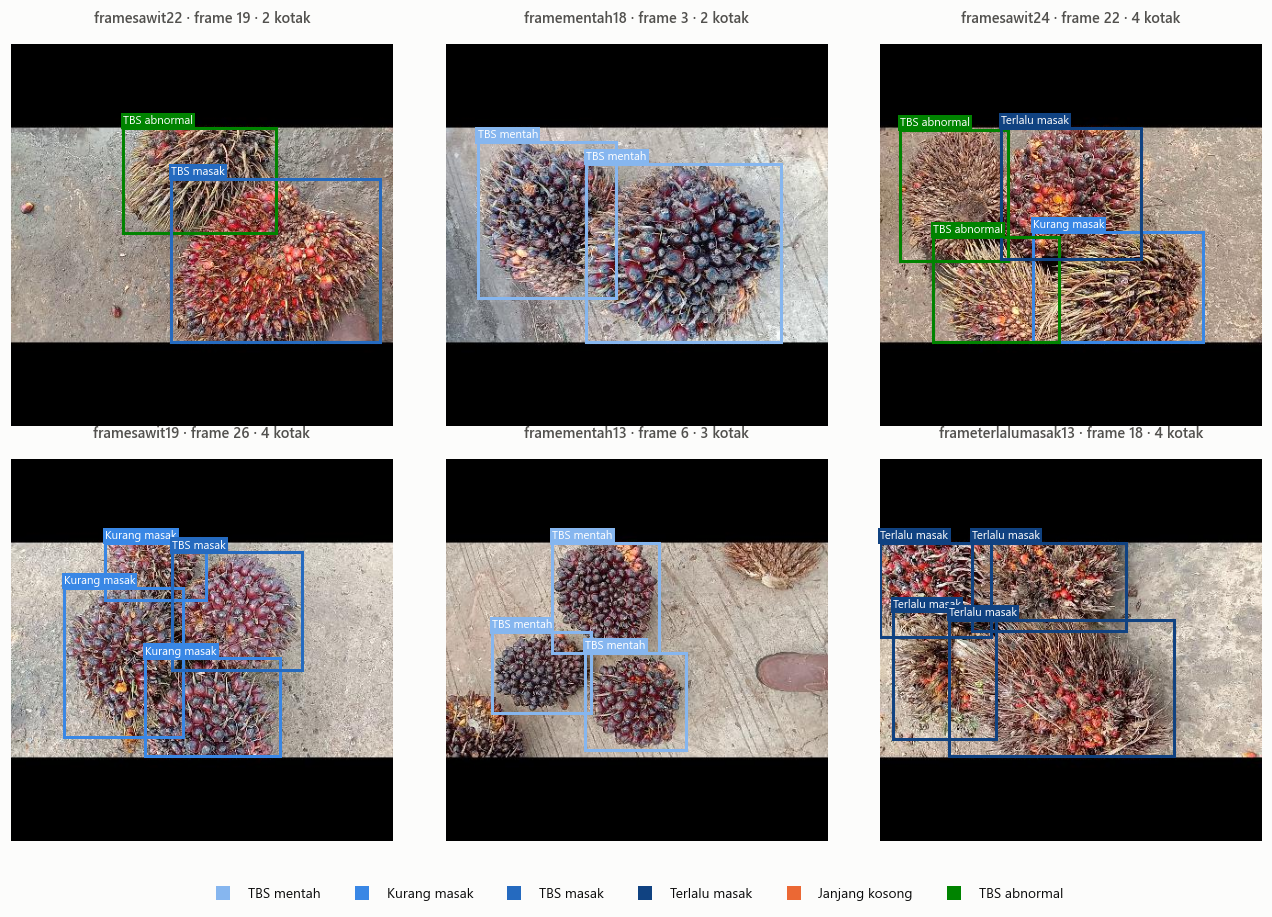

In [11]:
rng = np.random.default_rng(42)
sample = imgs[imgs.n_boxes >= 2].sample(6, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 8.2))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    im = Image.open(r["path"]).convert("RGB")
    ax.imshow(im)
    bb = boxes[boxes.file == r["file"]]
    for _, q in bb.iterrows():
        x1 = (q.x - q.w/2) * IMG; y1 = (q.y - q.h/2) * IMG
        col = vs.CLASS_COLORS[q.class_id]
        ax.add_patch(plt.Rectangle((x1, y1), q.w*IMG, q.h*IMG,
                     fill=False, edgecolor=col, linewidth=2.0))
        ax.text(x1, max(y1 - 4, 8), q.kelas, fontsize=7.5, color="#ffffff",
                bbox=dict(facecolor=col, edgecolor="none", pad=1.4))
    vs.strip_chart(ax)
    ax.set_title(f"{r['pile']} · frame {r['frame']} · {r['n_boxes']} kotak",
                 fontsize=9.5, color=vs.INK_SECONDARY)

handles = [plt.Line2D([0], [0], marker="s", linestyle="none", markersize=9,
                      markerfacecolor=vs.CLASS_COLORS[c], markeredgecolor="none",
                      label=vs.CLASS_NAMES[c])
           for c in vs.ORDINAL_ORDER + vs.NON_ORDINAL]
fig.legend(handles=handles, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(); plt.subplots_adjust(bottom=0.07); plt.show()

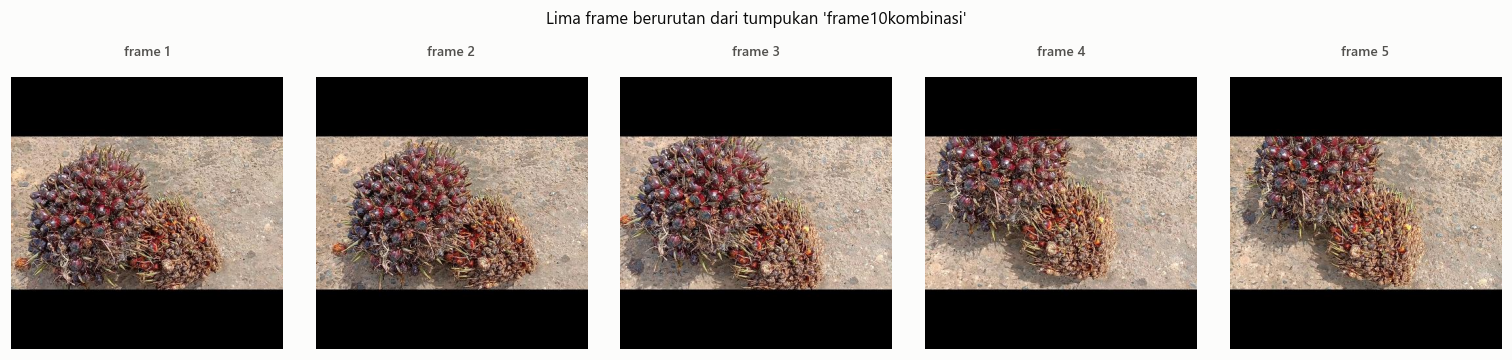

In [12]:
# Beberapa frame dari SATU tumpukan yang sama — memeriksa seberapa mirip
# frame bertetangga, karena inilah yang membuat split per gambar berbahaya.
target = per_pile.sort_values("gambar", ascending=False).iloc[0]["pile"]
same = imgs[imgs.pile == target].sort_values("frame").head(5)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.1))
for ax, (_, r) in zip(axes, same.iterrows()):
    ax.imshow(Image.open(r["path"]).convert("RGB"))
    vs.strip_chart(ax)
    ax.set_title(f"frame {r['frame']}", fontsize=9, color=vs.INK_SECONDARY)
fig.suptitle(f"Lima frame berurutan dari tumpukan '{target}'", y=1.04,
             fontsize=11, color=vs.INK)
plt.tight_layout(); plt.show()

## Kesimpulan

Enam temuan, diurutkan menurut dampaknya ke keputusan teknis.

### 1. Split resmi bocor sempurna — tidak bisa dipakai
Seluruh 91 tumpukan muncul di train; 100% tumpukan valid dan test juga ada di
train. Tidak ada satu pun tumpukan yang benar-benar belum pernah dilihat model.
Metrik dari split ini mengukur hafalan, bukan generalisasi.
**Tindakan:** bangun split berbasis tumpukan (Notebook 02), laporkan kedua angka.

### 2. Unit sampel sebenarnya 91, bukan 4.160
Rata-rata 45,7 frame per tumpukan. Untuk perhitungan statistik apa pun,
yang berlaku angka 91.

### 3. Sebaran frame per tumpukan sangat timpang
Median 39 frame, tetapi **maksimum 421** — satu tumpukan menyumbang ~10% seluruh
dataset. Split acak per tumpukan bisa membuat satu tumpukan mendominasi sisi uji.
**Tindakan:** perhatikan bobot frame saat membagi, bukan hanya jumlah tumpukan.

### 4. Objek justru BESAR, bukan kecil
84,5% kotak tergolong *large* menurut konvensi COCO, 15,5% *medium*, dan
**0% small**. Rasio lebar/tinggi median 1,11 (hampir persegi), median 4 objek
per gambar.
**Implikasi:** kekhawatiran bahwa resolusi 416x416 membatasi deteksi objek kecil
**tidak terbukti**. Resolusi ini memadai, dan tidak perlu waktu dihabiskan untuk
mengejar resolusi lebih tinggi. Adegannya juga tidak padat, sehingga tugas
deteksi relatif ringan.

### 5. Sebagian besar tumpukan direkam per kelas tunggal
Ini temuan paling halus dan paling penting:

| Kelompok | Komposisi |
|---|---|
| `framementah` | **100% TBS mentah** |
| `frameterlalumasak` | **100% Terlalu masak** |
| `framekurangmasak` | **100% Kurang masak** |
| `framesawit` | campuran (masak 33%, abnormal 31%, kurang masak 21%) |
| `frame` | campuran relatif merata |

Artinya sebagian tumpukan bukan muatan truk alami, melainkan **rekaman
terkurasi per tingkat kematangan**. Dua konsekuensinya:

- **Risiko jalan pintas.** Kalau seluruh tandan dalam satu adegan berlabel sama,
  model bisa belajar mengenali *adegan*, bukan membedakan *tandan*. Perlu diuji
  khusus pada tumpukan campuran.
- **Split wajib distratifikasi menurut kelompok.** Pembagian acak murni dapat
  memindahkan seluruh kelompok kelas tunggal ke satu sisi, sehingga kelas
  tertentu hilang sama sekali dari data uji.

### 6. Distribusi kelas sehat, kecuali satu
Lima kelas berada di kisaran 17,7–20,4%; hanya `Janjang kosong` yang minoritas
(5,89%). Tidak diperlukan penanganan ketidakseimbangan yang ekstrem, tetapi
metrik per kelas tetap harus dilaporkan terpisah.

---

### Catatan verifikasi angka

Publikasi menyebut **14.559** objek beranotasi; penghitungan langsung atas
berkas label menghasilkan **14.558**. Selisih satu kotak, kemungkinan baris
kosong atau pembulatan pelaporan. Angka yang dipakai di proposal adalah hasil
penghitungan langsung, dan selisih ini disebutkan apa adanya.

### Implikasi ke desain model

1. Detektor bekerja pada **tiga kelas struktural** (`tandan`, `janjang kosong`,
   `abnormal`); tingkat kematangan ditangani model ordinal terpisah pada crop.
   Ini memusatkan sinyal deteksi (11.102 kotak jadi satu kelas `tandan`) dan
   menghapus persoalan urutan `class_id` yang alfabetis.
2. Resolusi 416x416 **dipertahankan** — bukan kompromi, melainkan memadai.
3. Split per tumpukan, distratifikasi menurut kelompok, dengan memperhatikan
   bobot frame.
4. Evaluasi terpisah pada tumpukan campuran vs tumpukan kelas tunggal, untuk
   menguji apakah model benar-benar membedakan tandan.

In [13]:
print("=" * 68)
print("RINGKASAN TEMUAN — DATASET TUMPUKAN TBS")
print("=" * 68)
print(f"Gambar                     : {len(imgs):,}")
print(f"Kotak anotasi              : {len(boxes):,}")
print(f"Tumpukan unik              : {imgs['pile'].nunique()}")
print(f"Rata-rata frame/tumpukan   : {len(imgs)/imgs['pile'].nunique():.1f}")
print(f"Kotak per gambar (median)  : {imgs['n_boxes'].median():.0f}")
print(f"Objek 'small' COCO         : {(boxes['ukuran']=='small (<32²)').mean()*100:.1f}%")
print(f"Kelas paling minoritas     : {dist.iloc[-1]['kelas']} ({dist.iloc[-1]['persen']}%)")
bocor = len(ids['train'] & ids['test'])
print(f"Kebocoran train∩test       : {bocor} tumpukan "
      f"({bocor/len(ids['test'])*100:.0f}% dari test)")
print("=" * 68)

RINGKASAN TEMUAN — DATASET TUMPUKAN TBS
Gambar                     : 4,160
Kotak anotasi              : 14,558
Tumpukan unik              : 91
Rata-rata frame/tumpukan   : 45.7
Kotak per gambar (median)  : 4
Objek 'small' COCO         : 0.0%
Kelas paling minoritas     : Janjang kosong (5.89%)
Kebocoran train∩test       : 87 tumpukan (100% dari test)
